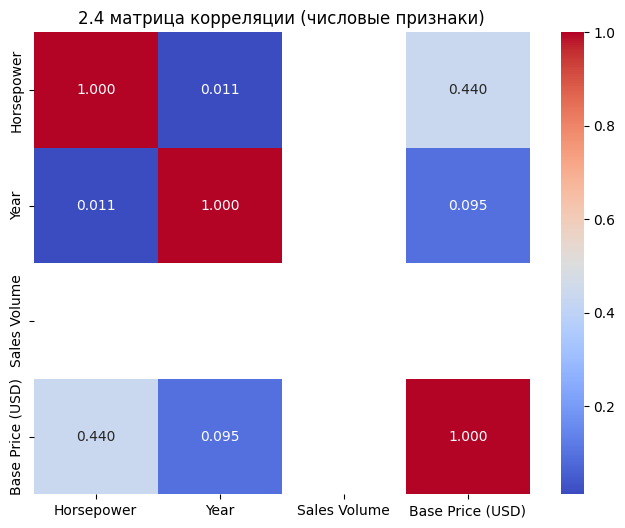

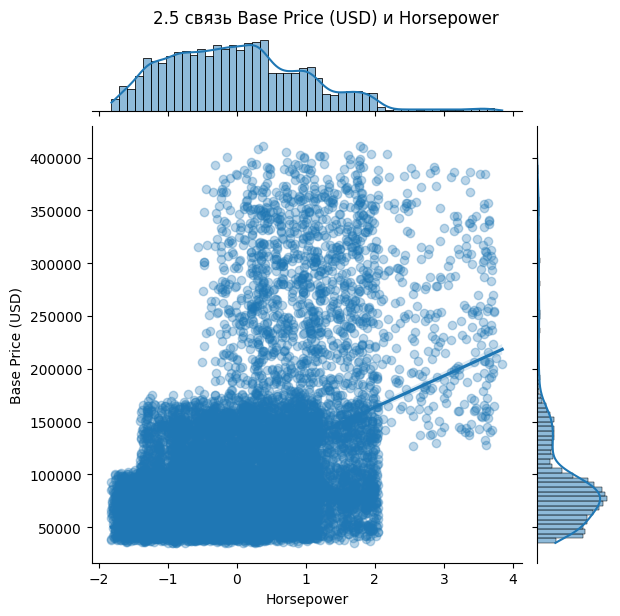

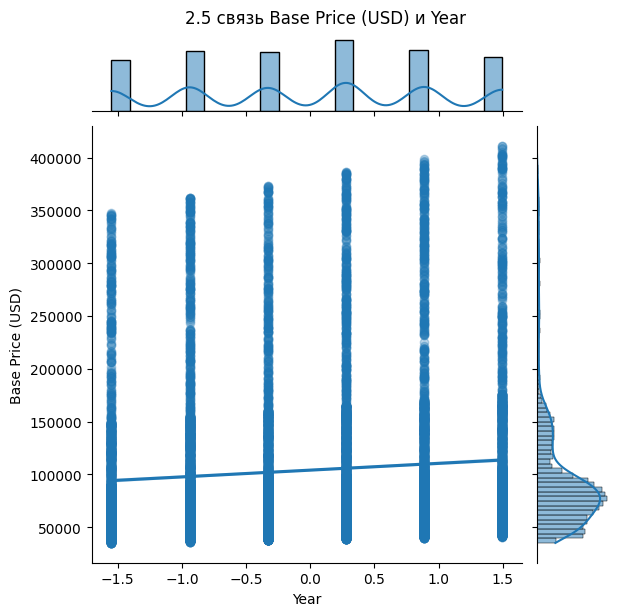

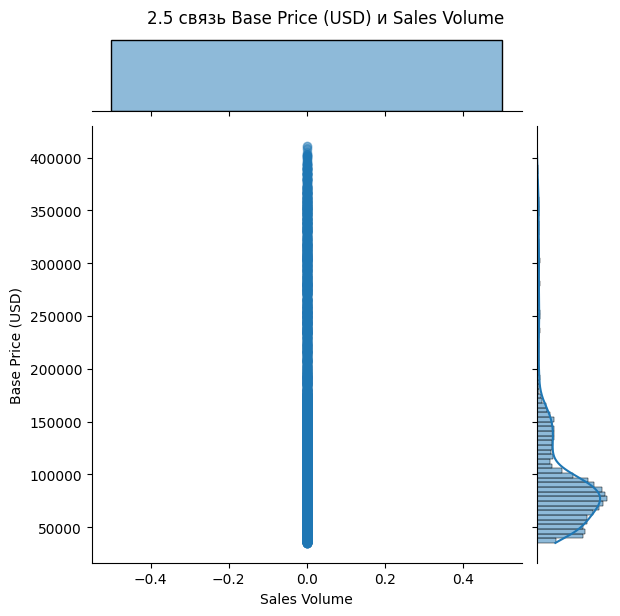


--- 3. регрессия мнк (этап 1) ---
MSE: 3507285423.60
MAE: 41175.99
R2: 0.2014
коэффициенты (model.coef_): [29812.06880882  6243.27908739     0.        ]
интерцепт (model.intercept_): 104236.13


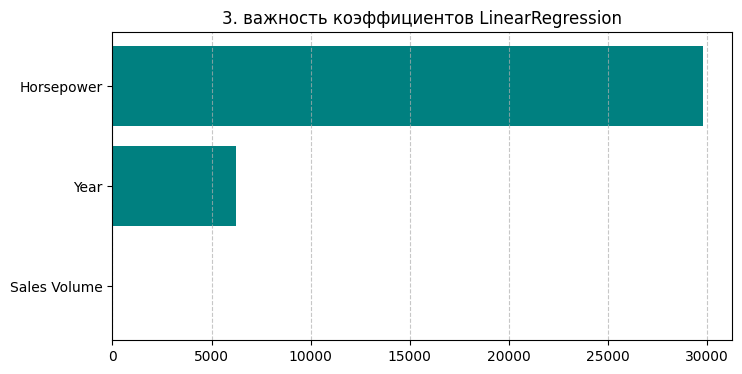


--- 4. модель Ridge (лучшие параметры: {'alpha': 10.0}) ---
R2: 0.2014, MSE: 3507245237.76
коэффициенты: [29787.29341385  6238.28621398     0.        ]


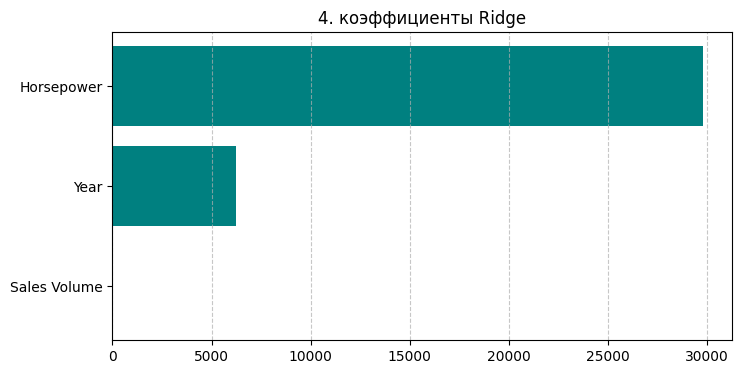


--- 4. модель Lasso (лучшие параметры: {'alpha': 10.0}) ---
R2: 0.2014, MSE: 3507255727.26
коэффициенты: [29802.14995786  6233.37837282     0.        ]


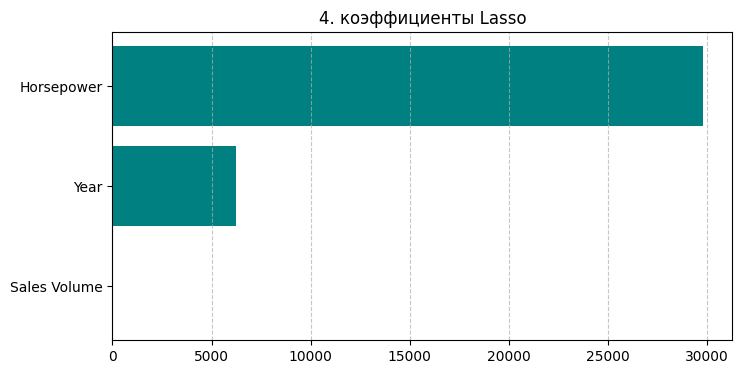


--- 4. модель ElasticNet (лучшие параметры: {'alpha': 0.1, 'l1_ratio': 0.7}) ---
R2: 0.2015, MSE: 3506644988.50
коэффициенты: [28945.29833616  6068.35534401     0.        ]


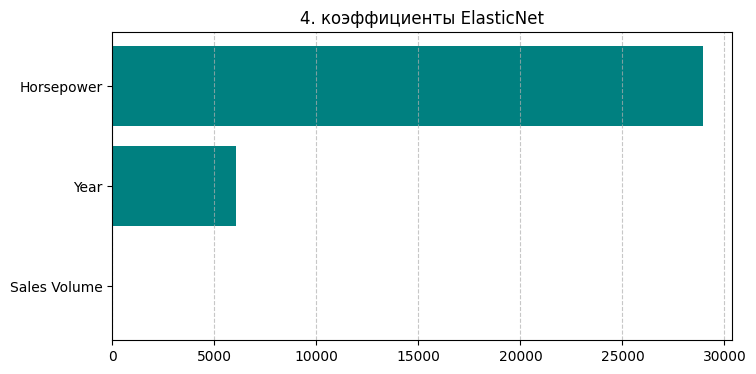


--- 4. модель kNN_Reg (лучшие параметры: {'n_neighbors': 11}) ---
R2: 0.1646, MSE: 3668815429.30

--- 4. модель RF_Reg (лучшие параметры: {'max_depth': 5, 'n_estimators': 50}) ---
R2: 0.2278, MSE: 3391478121.01


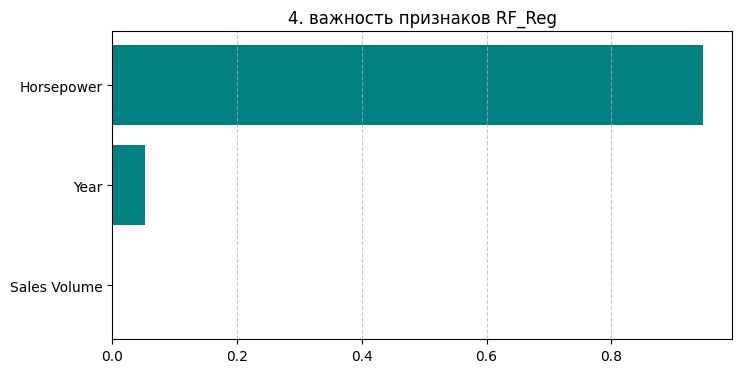


--- 6. сравнение моделей на полных данных (с категориями) ---
модель Ridge (с категориями) R2: 0.2520
модель Lasso (с категориями) R2: 0.2520
модель RF_Reg (с категориями) R2: 0.7451

--- 6. метрики после фильтрации признаков (SelectKBest) ---
R2: 0.7658
MAE: 23115.22


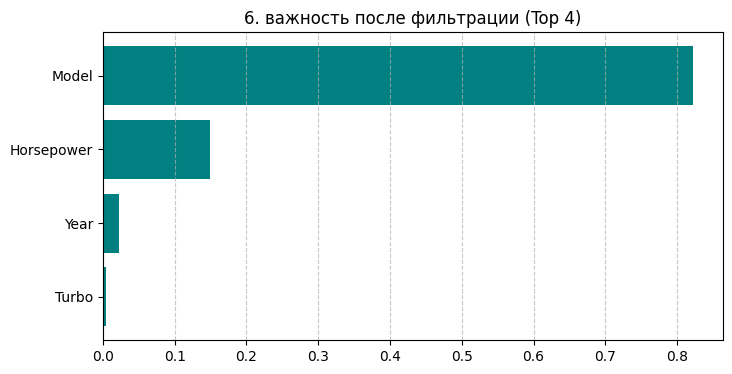

'\nвыводы:\n1. на первом этапе при использовании только числовых признаков (horsepower, year) модели показали низкую \n   точность (r2 около 0.20). это объясняется тем, что мощность двигателя лишь частично определяет цену, \n   а признак sales volume оказался константой и не внес вклада в прогноз.\n2. добавление категориальных признаков на втором этапе привело к значительному скачку качества. \n   метрика r2 для модели случайного леса (random forest) выросла с 0.22 до 0.74.\n3. самым важным признаком для предсказания цены оказалась модель автомобиля (model). график важности \n   показал, что именно принадлежность к определенной серии mercedes определяет стоимость сильнее всего.\n4. использование процедуры selectkbest с функцией f_regression позволило отобрать 4 наиболее значимых \n   признака. это не только упростило модель, но и улучшило итоговую метрику r2 до 0.7658, что \n   подтверждает эффективность удаления избыточных данных для улучшения обобщающей способности регрессора.\n5. лу

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline

# 1. считывание данных
df_full = pd.read_csv('/content/drive/MyDrive/Учёба/8 семестр/ТИИ/mercedes_benz_sales_2020_2025.csv')
df = df_full.sample(n=15000, random_state=42).copy()

# 2. подготовка данных, этап 1 (только числа)
# описание датасета
"""
датасет содержит данные о мировых продажах mercedes-benz 2020-2025.
цель — построение моделей регрессии для предсказания цены (Base Price (USD)).

таблица признаков:
признак            описание                          единицы измерения
Horsepower         мощность двигателя                лошадиные силы (число)
Year               год выпуска                       год (число)
Sales Volume       объем продаж                      штуки (число)
Model              модель автомобиля                 категория
Region             регион продажи                    категория
Fuel Type          тип двигателя                     категория
Turbo              наличие турбины                   категория
Base Price (USD)   целевая переменная (target)       доллары сша
"""

# этап 1: временно убираем категории
num_cols = ['Horsepower', 'Year', 'Sales Volume']
target_col = 'Base Price (USD)'
df_stage1 = df[num_cols + [target_col]].dropna()

# нормализация численных данных
scaler = StandardScaler()
df_stage1[num_cols] = scaler.fit_transform(df_stage1[num_cols])

# визуализация heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_stage1.corr(), annot=True, cmap='coolwarm', fmt='.3f')
plt.title('2.4 матрица корреляции (числовые признаки)')
plt.show()

# визуализация взаимосвязи target с каждым признаком (jointplot)
for col in num_cols:
    sns.jointplot(x=col, y=target_col, data=df_stage1, kind='reg', scatter_kws={'alpha':0.3})
    plt.suptitle(f'2.5 связь {target_col} и {col}', y=1.02)
    plt.show()

# разбиение выборки (этап 1)
x1_train, x1_test, y1_train, y1_test = train_test_split(df_stage1[num_cols], df_stage1[target_col], test_size=0.2, random_state=42)

# 3. регрессия МНК (LinearRegression)
lr = LinearRegression()
lr.fit(x1_train, y1_train)
y1_pred_lr = lr.predict(x1_test)

print("\n--- 3. регрессия мнк (этап 1) ---")
print(f"MSE: {mean_squared_error(y1_test, y1_pred_lr):.2f}")
print(f"MAE: {mean_absolute_error(y1_test, y1_pred_lr):.2f}")
print(f"R2: {r2_score(y1_test, y1_pred_lr):.4f}")
print(f"коэффициенты (model.coef_): {lr.coef_}")
print(f"интерцепт (model.intercept_): {lr.intercept_:.2f}")

# график barh для линейной регрессии
def plot_importance(importance, names, title):
    imp_df = pd.DataFrame({'feature': names, 'value': importance})
    imp_df = imp_df.sort_values(by='value', ascending=False)
    plt.figure(figsize=(8, 4))
    plt.barh(imp_df['feature'], imp_df['value'], color='teal')
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

plot_importance(lr.coef_, num_cols, "3. важность коэффициентов LinearRegression")

# 4. подбор параметров регуляризации и гиперпараметров
models_stage1 = {
    'Ridge': (Ridge(), {'alpha': [0.1, 1.0, 10.0, 100.0]}),
    'Lasso': (Lasso(), {'alpha': [0.1, 1.0, 10.0]}),
    'ElasticNet': (ElasticNet(), {'alpha': [0.1, 1.0], 'l1_ratio': [0.5, 0.7]}),
    'kNN_Reg': (KNeighborsRegressor(), {'n_neighbors': [3, 5, 11]}),
    'RF_Reg': (RandomForestRegressor(random_state=42), {'max_depth': [5, 10], 'n_estimators': [50]})
}

best_models_stage1 = {}

for name, (model, params) in models_stage1.items():
    grid = GridSearchCV(model, params, cv=5, scoring='r2')
    grid.fit(x1_train, y1_train)
    best_m = grid.best_estimator_
    best_models_stage1[name] = best_m

    y_p = best_m.predict(x1_test)
    print(f"\n--- 4. модель {name} (лучшие параметры: {grid.best_params_}) ---")
    print(f"R2: {r2_score(y1_test, y_p):.4f}, MSE: {mean_squared_error(y1_test, y_p):.2f}")

    if hasattr(best_m, 'coef_'):
        print(f"коэффициенты: {best_m.coef_}")
        plot_importance(best_m.coef_, num_cols, f"4. коэффициенты {name}")
    elif hasattr(best_m, 'feature_importances_'):
        plot_importance(best_m.feature_importances_, num_cols, f"4. важность признаков {name}")

# 5. подготовка данных, этап 2 (добавляем категории)
# возвращаемся к исходному df, кодируем категории
df_stage2 = df.drop(['Color'], axis=1).dropna() # уберем только цвет
le = LabelEncoder()
cat_features = ['Model', 'Region', 'Fuel Type', 'Turbo']
for col in cat_features:
    df_stage2[col] = le.fit_transform(df_stage2[col])

x2 = df_stage2.drop(target_col, axis=1)
y2 = df_stage2[target_col]

# разбиение с сохранением тех же индексов
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)

# масштабирование для 2 этапа
scaler2 = StandardScaler()
x2_train_scaled = scaler2.fit_transform(x2_train)
x2_test_scaled = scaler2.transform(x2_test)

# 6. регрессии, этап 2
print("\n--- 6. сравнение моделей на полных данных (с категориями) ---")
best_r2_stage2 = -1
best_model_name = ""

for name in ['Ridge', 'Lasso', 'RF_Reg']: # возьмем основные для сравнения
    m = best_models_stage1[name]
    m.fit(x2_train_scaled, y2_train)
    y2_pred = m.predict(x2_test_scaled)
    r2 = r2_score(y2_test, y2_pred)
    print(f"модель {name} (с категориями) R2: {r2:.4f}")

    if r2 > best_r2_stage2:
        best_r2_stage2 = r2
        best_model_name = name

# фильтрация признаков через SelectKBest (пункт 6.3)
pipeline = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_regression, k=4)),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))
])

pipeline.fit(x2_train_scaled, y2_train)
y2_pred_filt = pipeline.predict(x2_test_scaled)

print(f"\n--- 6. метрики после фильтрации признаков (SelectKBest) ---")
print(f"R2: {r2_score(y2_test, y2_pred_filt):.4f}")
print(f"MAE: {mean_absolute_error(y2_test, y2_pred_filt):.2f}")

# график важности для финальной модели
importances_final = pipeline.named_steps['regressor'].feature_importances_
mask = pipeline.named_steps['feature_selection'].get_support()
selected_names = x2.columns[mask]
plot_importance(importances_final, selected_names, "6. важность после фильтрации (Top 4)")

# 7. вывод
"""
выводы:
1. на первом этапе при использовании только числовых признаков (horsepower, year) модели показали низкую
   точность (r2 около 0.20). это объясняется тем, что мощность двигателя лишь частично определяет цену,
   а признак sales volume оказался константой и не внес вклада в прогноз.
2. добавление категориальных признаков на втором этапе привело к значительному скачку качества.
   метрика r2 для модели случайного леса (random forest) выросла с 0.22 до 0.74.
3. самым важным признаком для предсказания цены оказалась модель автомобиля (model). график важности
   показал, что именно принадлежность к определенной серии mercedes определяет стоимость сильнее всего.
4. использование процедуры selectkbest с функцией f_regression позволило отобрать 4 наиболее значимых
   признака. это не только упростило модель, но и улучшило итоговую метрику r2 до 0.7658, что
   подтверждает эффективность удаления избыточных данных для улучшения обобщающей способности регрессора.
5. лучшей моделью для данного датасета признан random forest regressor на отфильтрованном наборе признаков.
"""